In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import seaborn as sns   

In [2]:
WORKING_FILES_PATH = Path("../../working_files")
print(os.listdir(WORKING_FILES_PATH))

['args.yaml', 'BoxF1_curve.png', 'BoxPR_curve.png', 'BoxP_curve.png', 'BoxR_curve.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'labels.jpg', 'results.csv', 'results.png', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch14960.jpg', 'train_batch14961.jpg', 'train_batch14962.jpg', 'train_batch2.jpg', 'validation_metrics_sequence_1.csv', 'validation_metrics_sequence_2.csv', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg', 'weights']


In [3]:
results_df = pd.read_csv(WORKING_FILES_PATH / "results.csv")

In [4]:
print(results_df.columns)

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


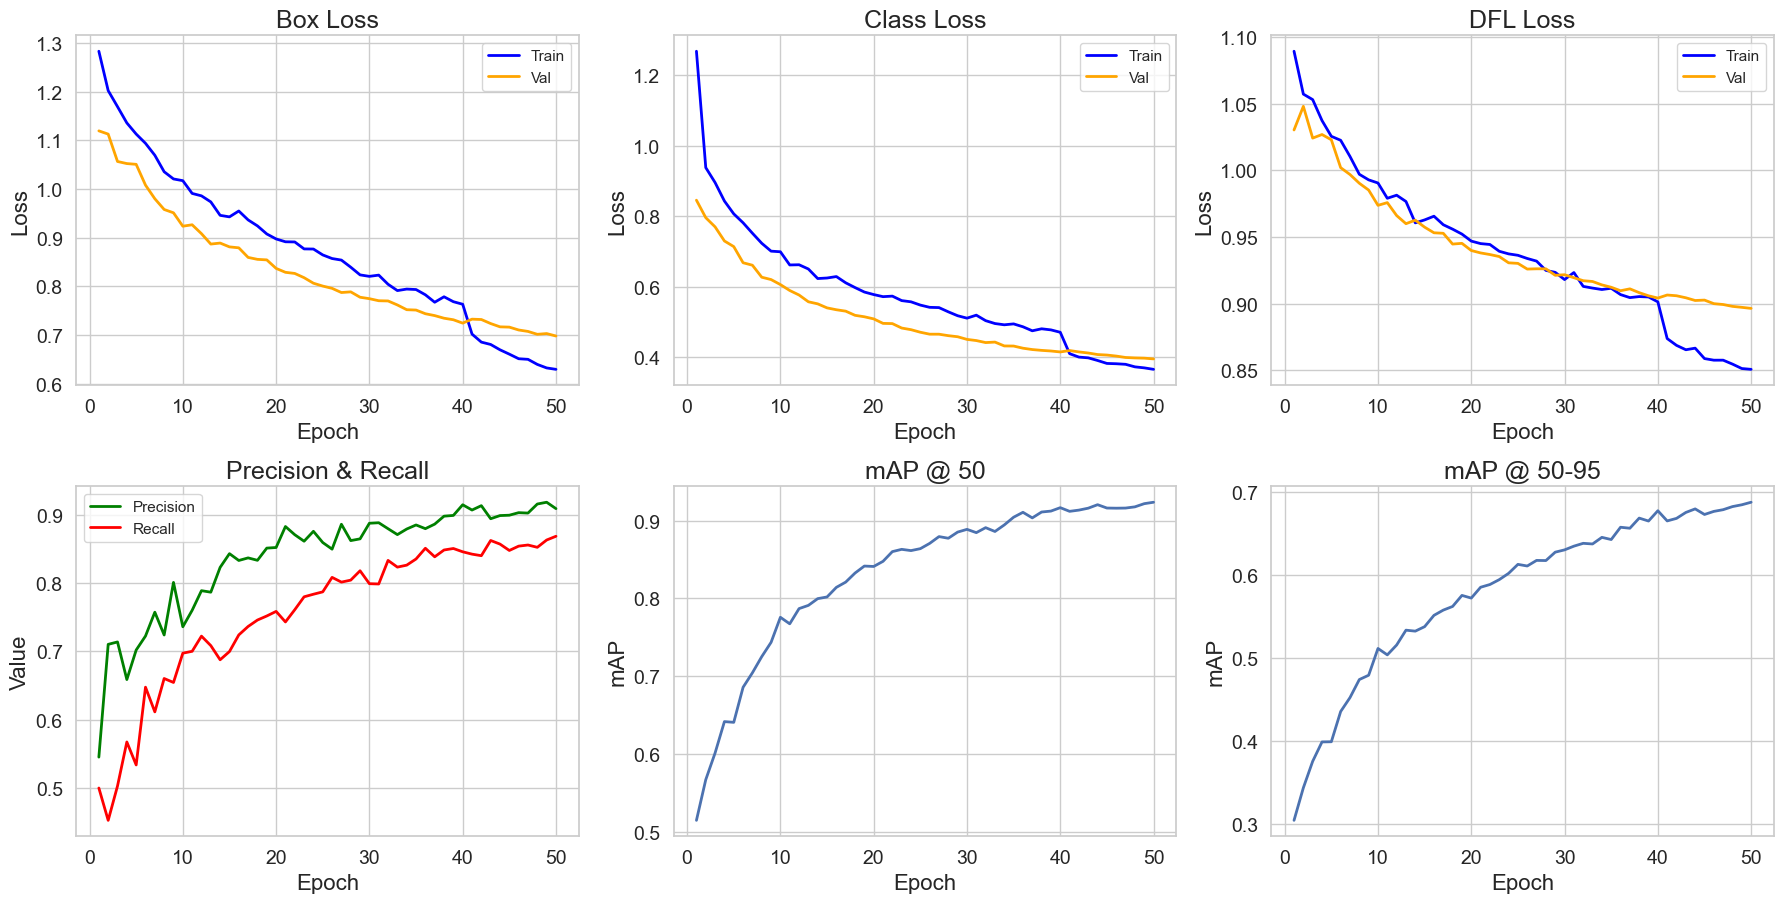

In [5]:

# Remove potential whitespace from column names
results_df.columns = results_df.columns.str.strip()

# Set up the plot style and size
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Helper function to plot
def plot_metric(ax, x, y_data, title, ylabel, labels=None, colors=None):
    if isinstance(y_data, list):
        for i, y in enumerate(y_data):
            label = labels[i] if labels else None
            color = colors[i] if colors else None
            sns.lineplot(x=x, y=y, ax=ax, label=label, color=color, linewidth=2)
    else:
        sns.lineplot(x=x, y=y_data, ax=ax, linewidth=2)
    
    ax.set_title(title, fontsize=18)
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    # Set the size of tick labels
    ax.tick_params(axis='both', which='major', labelsize=14)
    if labels:
        ax.legend()

# 1. Box Loss
plot_metric(
    axes[0, 0], results_df['epoch'], [results_df['train/box_loss'], results_df['val/box_loss']], 
    'Box Loss', 'Loss', labels=['Train', 'Val'], colors=['blue', 'orange'])

# 2. Cls Loss
plot_metric(
    axes[0, 1], results_df['epoch'], [results_df['train/cls_loss'], results_df['val/cls_loss']], 
    'Class Loss', 'Loss', labels=['Train', 'Val'], colors=['blue', 'orange'])

# 3. DFL Loss
plot_metric(
    axes[0, 2], results_df['epoch'], [results_df['train/dfl_loss'], results_df['val/dfl_loss']], 
    'DFL Loss', 'Loss', labels=['Train', 'Val'], colors=['blue', 'orange'])

# 4. Precision & Recall
plot_metric(
    axes[1, 0], results_df['epoch'], [results_df['metrics/precision(B)'], results_df['metrics/recall(B)']], 
    'Precision & Recall', 'Value', labels=['Precision', 'Recall'], colors=['green', 'red'])

# 5. mAP50
plot_metric(
    axes[1, 1], results_df['epoch'], results_df['metrics/mAP50(B)'], 
    'mAP @ 50', 'mAP', colors=['purple'])

# 6. mAP50-95
plot_metric(
    axes[1, 2], results_df['epoch'], results_df['metrics/mAP50-95(B)'], 
    'mAP @ 50-95', 'mAP', colors=['purple'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.savefig('training_metrics.png', dpi=300)

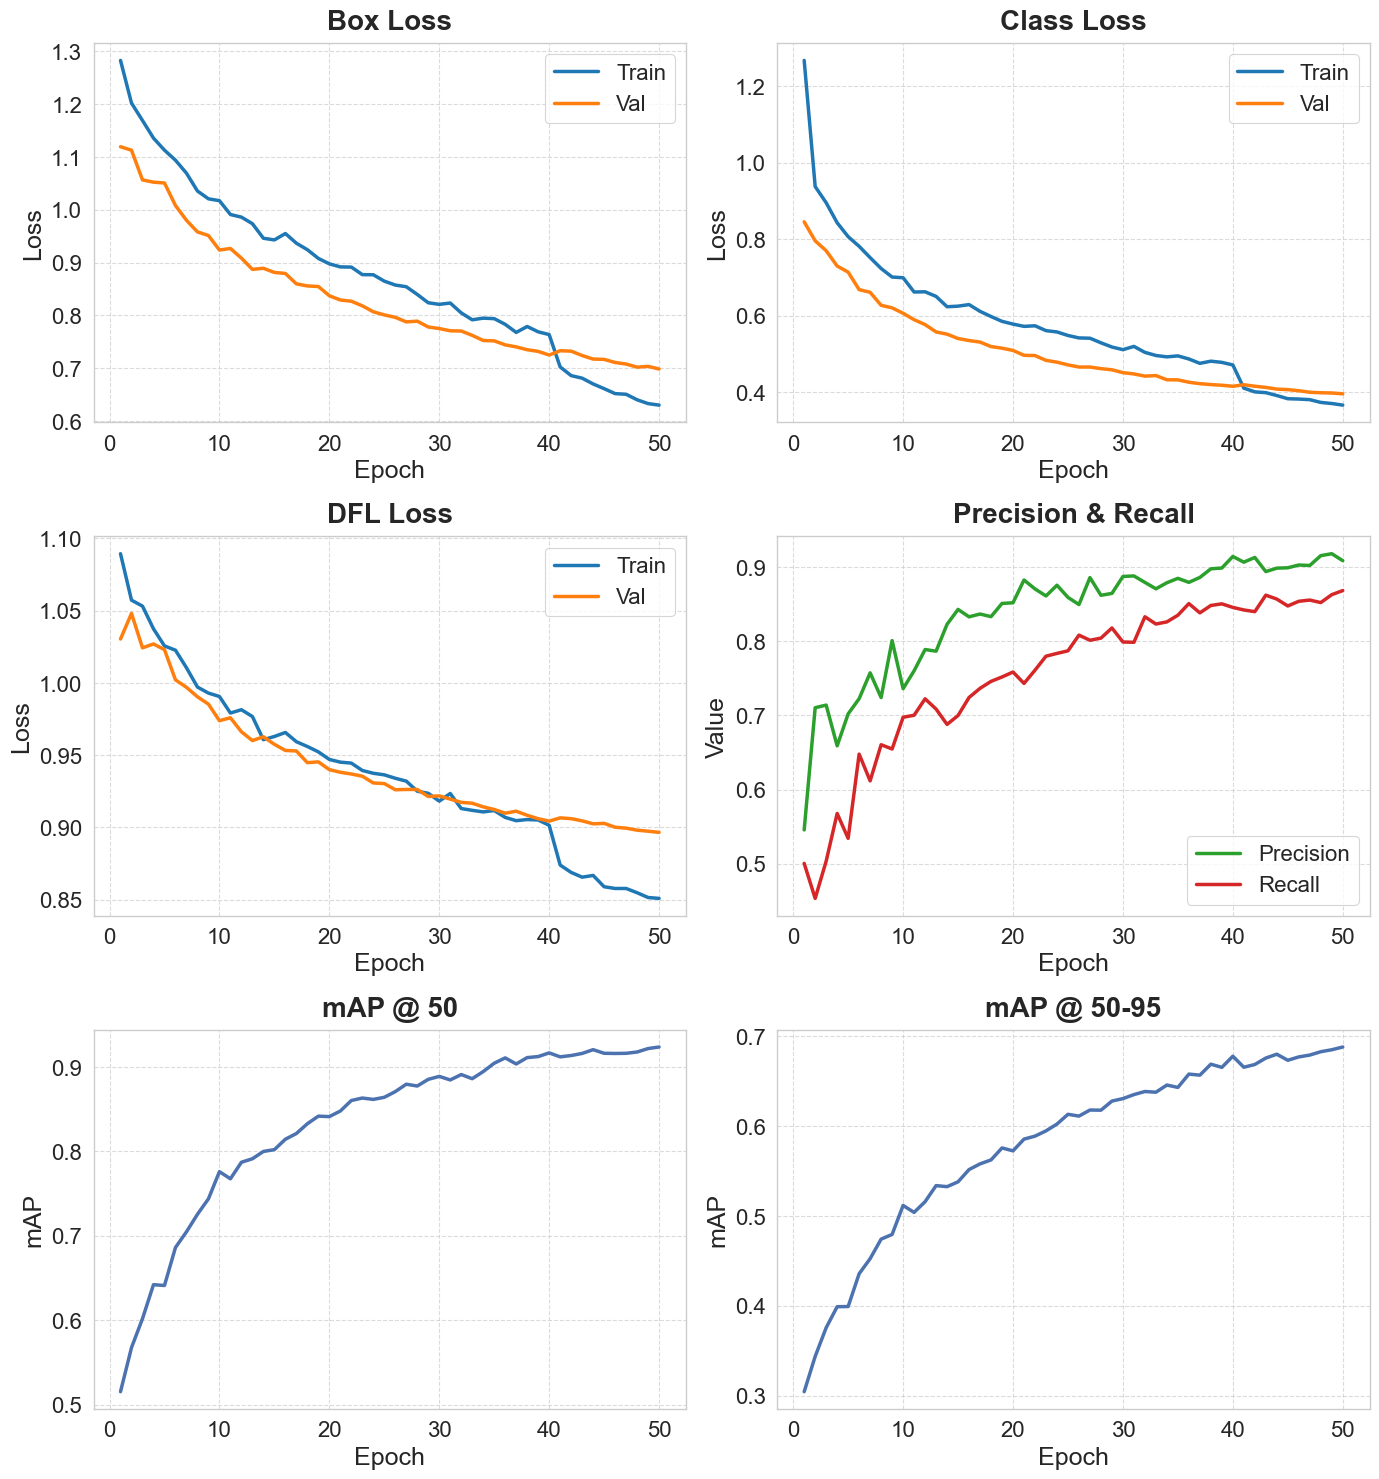

In [ ]:
# Set up the plot style and context
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4) 

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Helper function to plot
def plot_metric(ax, x, y_data, title, ylabel, labels=None, colors=None):
    """ 
    Plots a metric on the given axes.
    :param ax: Matplotlib Axes object to plot on.
    :param x: X-axis data (epochs).
    :param y_data: Y-axis data (metric values). Can be a list for multiple lines.
    :param title: Title of the plot.
    :param ylabel: Label for the Y-axis.
    :param labels: List of labels for multiple lines (if applicable).
    :param colors: List of colors for multiple lines (if applicable).
    :return: None
    """
    if isinstance(y_data, list):
        for i, y in enumerate(y_data):
            label = labels[i] if labels else None
            color = colors[i] if colors else None
            sns.lineplot(x=x, y=y, ax=ax, label=label, color=color, linewidth=2.5)
    else:
        sns.lineplot(x=x, y=y_data, ax=ax, linewidth=2.5)
    
    ax.set_title(title, fontsize=20, fontweight='bold', pad=10)
    ax.set_xlabel('Epoch', fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    if labels:
        ax.legend(fontsize=16)

# 1. Box Loss
plot_metric(
    axes[0, 0], results_df['epoch'], [results_df['train/box_loss'], results_df['val/box_loss']], 
    'Box Loss', 'Loss', labels=['Train', 'Val'], colors=['#1f77b4', '#ff7f0e'])

# 2. Cls Loss
plot_metric(
    axes[0, 1], results_df['epoch'], [results_df['train/cls_loss'], results_df['val/cls_loss']], 
    'Class Loss', 'Loss', labels=['Train', 'Val'], colors=['#1f77b4', '#ff7f0e'])

# 3. DFL Loss
plot_metric(
    axes[1, 0], results_df['epoch'], [results_df['train/dfl_loss'], results_df['val/dfl_loss']], 
    'DFL Loss', 'Loss', labels=['Train', 'Val'], colors=['#1f77b4', '#ff7f0e'])

# 4. Precision & Recall
plot_metric(
    axes[1, 1], results_df['epoch'], [results_df['metrics/precision(B)'], results_df['metrics/recall(B)']], 
    'Precision & Recall', 'Value', labels=['Precision', 'Recall'], colors=['#2ca02c', '#d62728'])

# 5. mAP50
plot_metric(
    axes[2, 0], results_df['epoch'], results_df['metrics/mAP50(B)'], 
    'mAP @ 50', 'mAP', colors=['#9467bd'])

# 6. mAP50-95
plot_metric(
    axes[2, 1], results_df['epoch'], results_df['metrics/mAP50-95(B)'], 
    'mAP @ 50-95', 'mAP', colors=['#9467bd'])


plt.tight_layout()
plt.savefig('training_metrics_vertical.png', dpi=300, bbox_inches='tight')

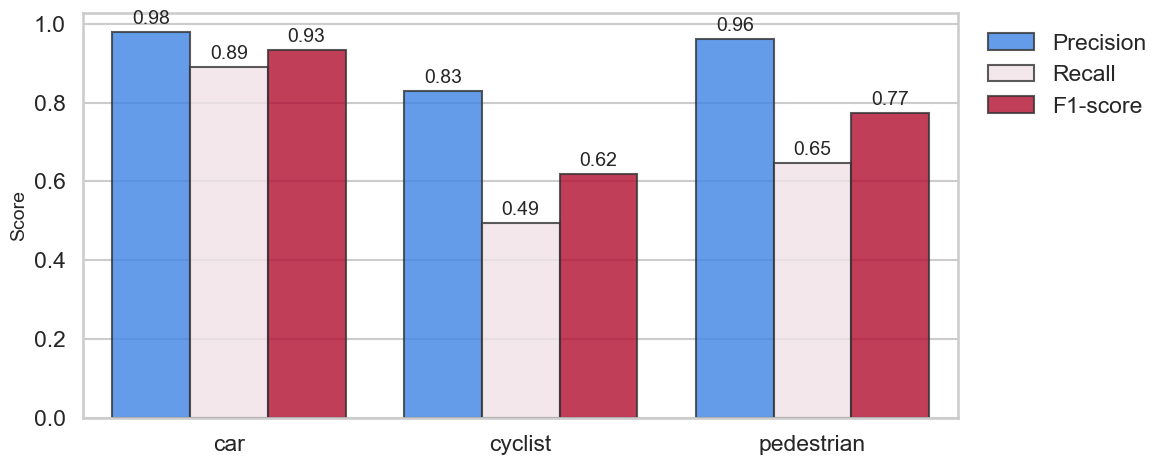

In [ ]:
# Read the validation metrics for sequences
val_metrics_seq_1 = pd.read_csv(WORKING_FILES_PATH / 'validation_metrics_sequence_1.csv')
val_metrics_seq_2 = pd.read_csv(WORKING_FILES_PATH / 'validation_metrics_sequence_2.csv')

# Sum the raw counts (TP, FP, FN) first. This handles different dataset sizes correctly.
combined_df = pd.concat([val_metrics_seq_1, val_metrics_seq_2])
grouped = combined_df.groupby('Class')[['TP', 'FP', 'FN']].sum().reset_index()

# Recalculate Metrics based on aggregated counts
grouped['Precision'] = grouped['TP'] / (grouped['TP'] + grouped['FP'])
grouped['Recall'] = grouped['TP'] / (grouped['TP'] + grouped['FN'])
grouped['F1-score'] = 2 * (grouped['Precision'] * grouped['Recall']) / (grouped['Precision'] + grouped['Recall'])

# Fill NaNs with 0 in case of division by zero
grouped = grouped.fillna(0)

# Prepare data for plotting
plot_data = grouped.melt(
    id_vars='Class', value_vars=['Precision', 'Recall', 'F1-score'], 
    var_name='Metric', value_name='Score')

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(12, 5))

colors = ["#3F84E5", "#F0E2E7", "#B20D30"]
# colors = ["#E15554", "#4D9DE0", "#E1BC29"]
# colors = ["#003f5c", "#bc5090", "#ffa600"]


# Create grouped bar chart
ax = sns.barplot(
    data=plot_data, 
    x='Class', 
    y='Score', 
    hue='Metric', 
    edgecolor=".2",
    # Set the custom colors
    hue_order=['Precision', 'Recall', 'F1-score'],
    palette=colors,
    saturation=1,
    alpha=0.8
    
)

plt.ylabel('Score', fontsize=14)
plt.xlabel('')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

# Add numeric annotations
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=14)

plt.tight_layout()
plt.show()

In [7]:
2 * (0.941 * 0.458)  / (0.941 + 0.458) 

0.6161229449606862